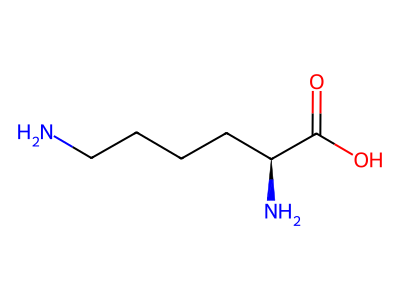

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles = "NCCCC[C@@H](N)C(=O)O"  

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)



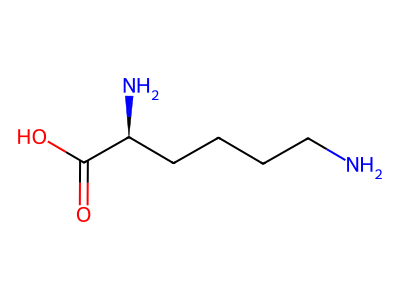

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles = "N[C@@H](CCCCN)C(=O)O"  # L-Lysine

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)

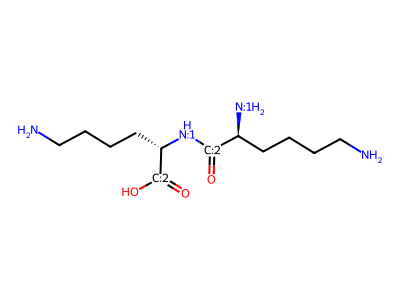

In [31]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles = "[NH2:1][C@@H](CCCCN)[C:2](=O)[NH1:1][C@@H](CCCCN)[C:2](=O)O"  # L-Lysine

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)

## BONUS: Checking Chirality in Molecules Using RDKit (Example: Isoleucine)

This code allows you to visualize a molecule from its SMILES, identify its chiral centers, and check if the assigned chirality matches the expected configuration. It is useful for spotting potential errors in the chirality assignment of amino acids and peptides.

Chirality Concepts

- R/S: absolute configuration of substituents around a chiral carbon.

    - R (rectus) → clockwise orientation.

    - S (sinister) → counterclockwise orientation.

- L/D: relative to glyceraldehyde.

    - Most natural amino acids are L and correspond to S, except for cysteine, which is L but R.

This distinction helps detect assignment errors, e.g., L with R or D with S, which is especially important if you are planning to add a new amino acid and want to ensure the chirality is assigned correctly.

SMILES: N[C@@H](CC=C)C(=O)O
Chiral centers (atom index, configuration): [(1, 'S')]
----------------------------------------


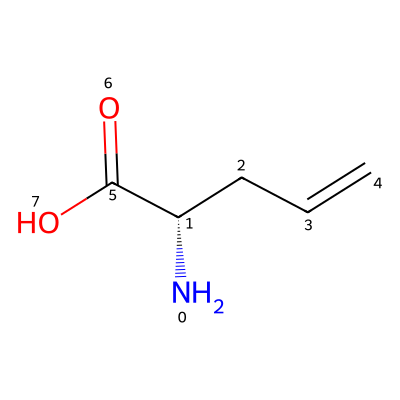

In [24]:
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image
from io import BytesIO
from IPython.display import display

# Define the SMILES of the molecule (example: isoleucine with defined chirality)
smiles = 'N[C@@H](CC=C)C(=O)O'

# Create an RDKit molecule object from the SMILES
mol = Chem.MolFromSmiles(smiles)

# Detect chiral centers in the molecule
# includeUnassigned=True also includes chiral carbons without assigned configuration
chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)

# Display the original SMILES
print(f"SMILES: {smiles}")

# Display the detected chiral centers
if chiral_centers:
    print("Chiral centers (atom index, configuration):", chiral_centers)
else:
    print("No chiral centers found.")
    
print("-"*40)

drawer = Draw.MolDraw2DCairo(400, 400)
drawer.drawOptions().addAtomIndices = True
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
png_data = drawer.GetDrawingText()
img = Image.open(BytesIO(png_data))
display(img)